In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\user\\ML PROJECTS\\Data Sets\\fraudTest.csv")

In [3]:
df.shape

(555719, 23)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  str    
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  str    
 4   category               555719 non-null  str    
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  str    
 7   last                   555719 non-null  str    
 8   gender                 555719 non-null  str    
 9   street                 555719 non-null  str    
 10  city                   555719 non-null  str    
 11  state                  555719 non-null  str    
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-null  float64

In [5]:
# in this data there is is_fraud column check 
df["is_fraud"].unique()

array([0, 1])

In [6]:
# checking  the missing values 
print(df.isnull().sum())

print("\n No Null values in the dataset","_"*50)

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

 No Null values in the dataset __________________________________________________


In [7]:
# checking the datatypes
df.dtypes

Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

In [8]:
# cheking the duplicated values 
print(df.duplicated().sum())

print("\n No Duplicate values ","_"*50)

0

 No Duplicate values  __________________________________________________


# Analyze and Report 



In [9]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


Hear   in thr data there is  no unnamed column we need to drop and hear 

In [10]:
df.drop("Unnamed: 0",axis = 1 ,inplace = True)

In [11]:
# converting  date column to datetime object
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"] = pd.to_datetime(df["dob"])

In [12]:
df.sample(7)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
481371,2020-12-15 07:50:02,30501624614310,fraud_Kuphal-Bartoletti,misc_net,1.13,Amanda,Smith,F,180 Graves Shore,Scotia,...,32.6786,-81.2455,302,Magazine features editor,1973-05-04,71d35b0da4f714fbc7ed5046b578421b,1387093802,31.728035,-81.879458,0
37512,2020-07-04 14:53:09,4018105808392773675,fraud_Rau-Grant,kids_pets,22.93,Katherine,Love,F,5884 Sandoval Square Apt. 371,Allenhurst,...,40.2367,-74.0067,1533,"Administrator, charities/voluntary organisations",1935-04-15,8da0f18b2046368048f369f73d903c67,1372949589,40.708460,-73.915974,0
167235,2020-08-18 15:03:44,4610064888664703,fraud_Kirlin and Sons,personal_care,28.43,Tammy,Maldonado,F,3312 Rachel Parks Suite 474,Stittville,...,43.2229,-75.2899,847,Systems analyst,1996-01-11,6491f196a3f8324aa4fb59c9eb7c4fb6,1376838224,43.445605,-75.971381,0
171359,2020-08-20 07:15:28,341542810616333,"fraud_Larkin, Stracke and Greenfelder",entertainment,57.31,Billy,Mcdonald,M,304 Ryan Port Suite 335,Camden,...,39.2048,-94.0259,464,Colour technologist,1959-05-28,4e74b4bbe1614d311497ef6f9008783f,1376982928,38.686783,-93.151771,0
352459,2020-11-03 23:29:32,2286236465059468,fraud_Gottlieb Group,kids_pets,72.37,Morgan,Murray,F,2788 Brittney Island,Blairstown,...,38.5319,-93.9221,467,Agricultural consultant,1950-05-27,0940d05c4c755b0ab6707a623500f0f5,1383521372,38.062191,-94.633127,0
139986,2020-08-09 14:13:06,675909898057,fraud_Eichmann-Kilback,home,104.20,Christopher,Henry,M,1198 Robert Stravenue Apt. 479,Armonk,...,41.1360,-73.7009,7987,Television/film/video producer,1964-03-16,f2d8fe6a142bbefb11afe35a3fc4bf3f,1376057586,40.647190,-72.827961,0
216271,2020-09-06 07:44:51,4171397999167005,"fraud_Robel, Cummerata and Prosacco",gas_transport,48.15,Ashley,Mcdonald,F,3160 Tina Estates Suite 234,Marietta,...,35.0296,-82.5136,5648,Museum/gallery exhibitions officer,1934-10-06,27be2497d2281d25c243975ea5f75c76,1378453491,35.639637,-81.739155,0


In [13]:
# extracting the day and hour  from trans_date_trans_time
df["trans_hour"] = df["trans_date_trans_time"].dt.hour
df["trans_day"] = df["trans_date_trans_time"].dt.day

df.drop("trans_date_trans_time",axis = 1 , inplace = True)

Checking the all datatypes if not anything is wrong  then  convert it  after that we need to check outliers using  with EDA part

In [14]:
df.columns.astype("category" )

CategoricalIndex(['cc_num', 'merchant', 'category', 'amt', 'first', 'last',
                  'gender', 'street', 'city', 'state', 'zip', 'lat', 'long',
                  'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
                  'merch_lat', 'merch_long', 'is_fraud', 'trans_hour',
                  'trans_day'],
                 categories=['amt', 'category', 'cc_num', 'city', ..., 'trans_hour', 'trans_num', 'unix_time', 'zip'], ordered=False, dtype='category')

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   cc_num      555719 non-null  int64         
 1   merchant    555719 non-null  str           
 2   category    555719 non-null  str           
 3   amt         555719 non-null  float64       
 4   first       555719 non-null  str           
 5   last        555719 non-null  str           
 6   gender      555719 non-null  str           
 7   street      555719 non-null  str           
 8   city        555719 non-null  str           
 9   state       555719 non-null  str           
 10  zip         555719 non-null  int64         
 11  lat         555719 non-null  float64       
 12  long        555719 non-null  float64       
 13  city_pop    555719 non-null  int64         
 14  job         555719 non-null  str           
 15  dob         555719 non-null  datetime64[us]
 16  trans_num   5

In [16]:
df.head()

,cc_num,merchant,category,amt,first,last,gender,street,city,state,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_day
0,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,...,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,12,21
1,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,...,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,12,21
2,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,...,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,12,21
3,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,...,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,12,21
4,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,...,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,12,21


### Everything is fine so we need  t0 chek theoutliers usong EDA 

In [17]:
df.describe()

,cc_num,amt,zip,lat,long,city_pop,dob,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_day
count,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,555719,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,555719.000000
mean,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1973-11-11 16:30:05.937173,1.380679e+09,38.542798,-90.231380,0.003860,12.809062,16.463904
min,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1924-10-30 00:00:00,1.371817e+09,19.027422,-166.671575,0.000000,0.000000,1.000000
25%,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1962-09-27 00:00:00,1.376029e+09,34.755302,-96.905129,0.000000,7.000000,9.000000
50%,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1975-11-30 00:00:00,1.380762e+09,39.376593,-87.445204,0.000000,14.000000,17.000000
75%,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1987-04-23 00:00:00,1.385867e+09,41.954163,-80.264637,0.000000,19.000000,24.000000
max,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,2005-01-29 00:00:00,1.388534e+09,66.679297,-66.952026,1.000000,23.000000,31.000000
std,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,NaN,5.201104e+06,5.095829,13.733071,0.062008,6.810924,8.955311


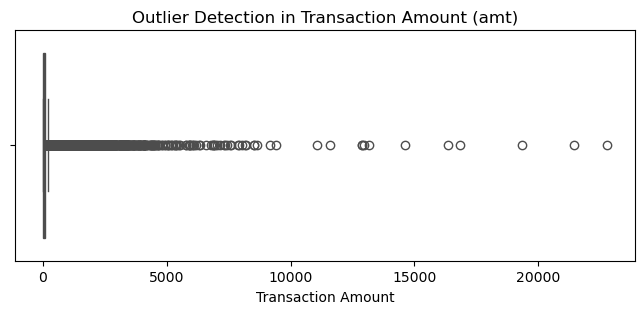

In [18]:
# Visualizing Outliers in Transaction Amount using a Boxplot
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['amt'], color='red')
plt.title('Outlier Detection in Transaction Amount (amt)')
plt.xlabel('Transaction Amount')
plt.show()



C:\Users\user\AppData\Local\Temp\ipykernel_12800\2805354086.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df,x = "is_fraud", palette="Set2")


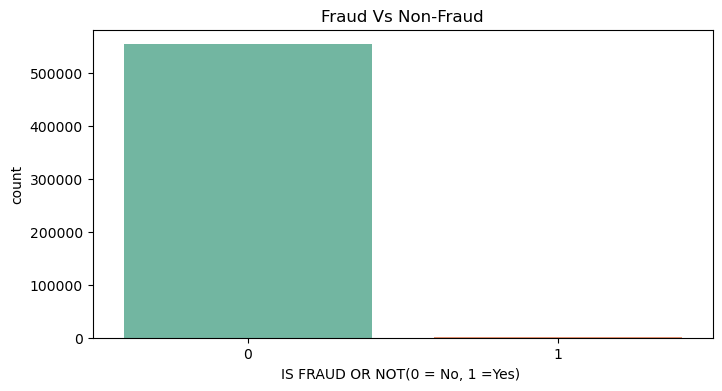

In [19]:
# Fraud vs Non-Fraud
plt.figure(figsize = (8,4))
sns.countplot(data = df,x = "is_fraud", palette="Set2")
plt.title("Fraud Vs Non-Fraud")
plt.xlabel("IS FRAUD OR NOT(0 = No, 1 =Yes) ")
plt.ylabel("count")
plt.show()

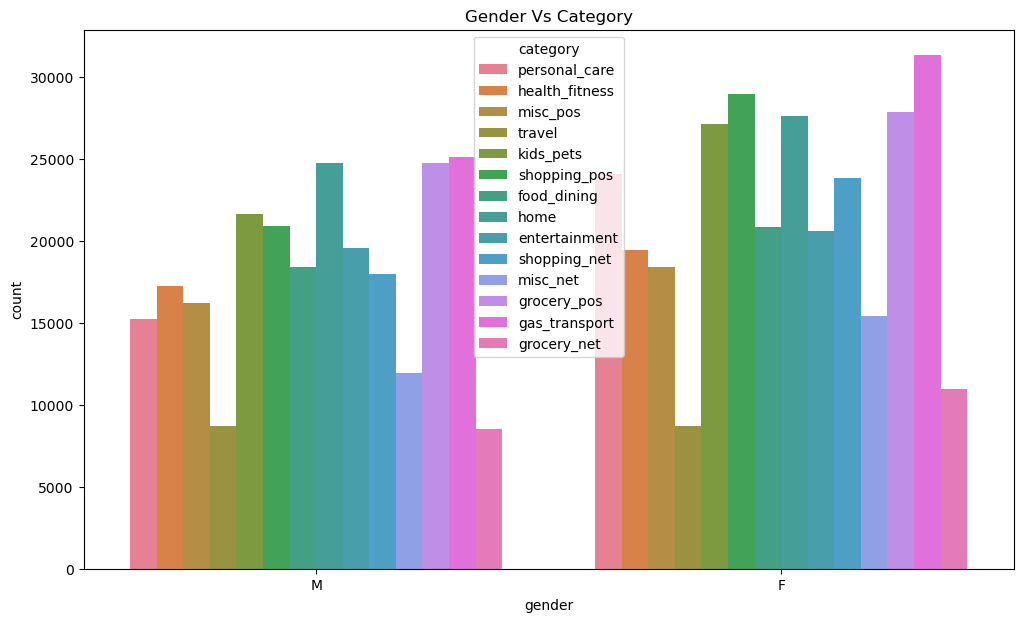

In [20]:
# in which category  they spend more money  male  and female using of barplot
plt.figure(figsize=(12,7))
sns.countplot(x="gender", hue="category", data=df)
plt.title("Gender Vs Category")
plt.show()

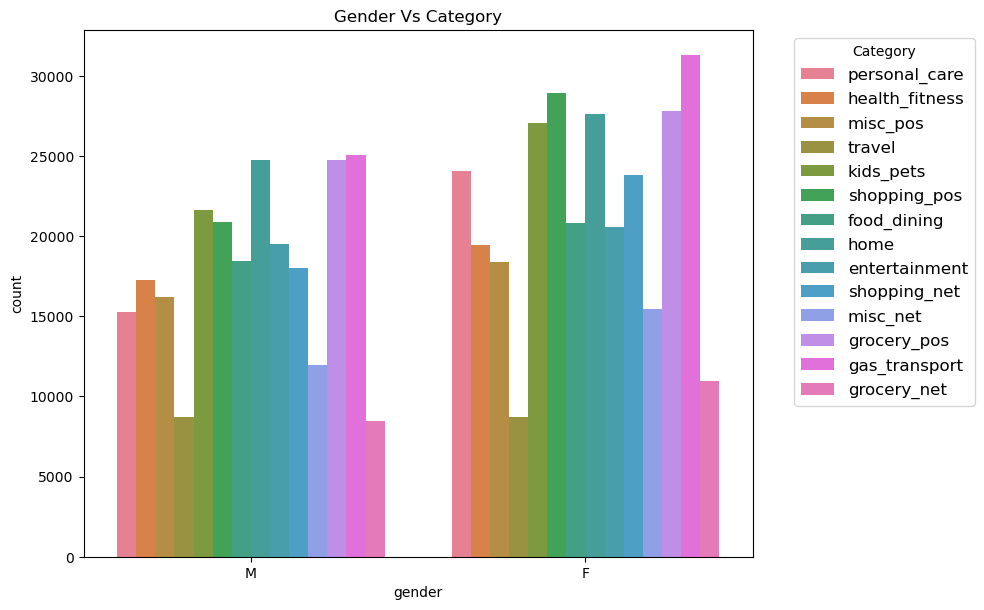

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(x="gender", hue="category", data=df)

# 2. Move and resize the legend
plt.legend(
    title="Category",          
    bbox_to_anchor=(1.05, 1),  
    loc='upper left',          
    fontsize='large'        
)
plt.tight_layout() 
plt.title("Gender Vs Category")
plt.show()

## Encoding 


Encoding:- Convert  the  categercal data into a  numerical data


label encoding and one-hot-encoding

Encoding done by  data  if its data like a boolean then we need to use label(eg: Yes or No, True or False, Male or Female  etc......)

one-hot-encosing : all type of categorical data  we use one-hot-encoding 

In [22]:
# import ML lib
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

In [23]:
df.head()

,cc_num,merchant,category,amt,first,last,gender,street,city,state,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_day
0,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,...,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,12,21
1,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,...,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,12,21
2,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,...,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,12,21
3,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,...,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,12,21
4,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,...,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,12,21


In [24]:
# label encosing for  two columns  gender and is_fraud 
le = LabelEncoder() # creating a instance 

df["gender"] = le.fit_transform(df["gender"]) # encoding the gender column
df["is_fraud"] = le.fit_transform(df["is_fraud"]) # encoding the is_fraud column


In [25]:
# 1. Print all available columns to check the exact spelling
print(df.columns)

# 2. Safe check before encoding (so it won't crash if it's missing)
if 'gender' in df.columns:
    le = LabelEncoder()
    df['gender'] = le.fit_transform(df['gender'])
    print("Gender encoded successfully!")
else:
    print("Column 'gender' not found in DataFrame.")

Index(['cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender',
       'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job',
       'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud',
       'trans_hour', 'trans_day'],
      dtype='str')
Gender encoded successfully!


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   cc_num      555719 non-null  int64         
 1   merchant    555719 non-null  str           
 2   category    555719 non-null  str           
 3   amt         555719 non-null  float64       
 4   first       555719 non-null  str           
 5   last        555719 non-null  str           
 6   gender      555719 non-null  int64         
 7   street      555719 non-null  str           
 8   city        555719 non-null  str           
 9   state       555719 non-null  str           
 10  zip         555719 non-null  int64         
 11  lat         555719 non-null  float64       
 12  long        555719 non-null  float64       
 13  city_pop    555719 non-null  int64         
 14  job         555719 non-null  str           
 15  dob         555719 non-null  datetime64[us]
 16  trans_num   5

In [27]:
# One-hot_encoding 
df = pd.get_dummies(df, columns=['category'], prefix='category')

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   cc_num                   555719 non-null  int64         
 1   merchant                 555719 non-null  str           
 2   amt                      555719 non-null  float64       
 3   first                    555719 non-null  str           
 4   last                     555719 non-null  str           
 5   gender                   555719 non-null  int64         
 6   street                   555719 non-null  str           
 7   city                     555719 non-null  str           
 8   state                    555719 non-null  str           
 9   zip                      555719 non-null  int64         
 10  lat                      555719 non-null  float64       
 11  long                     555719 non-null  float64       
 12  city_pop                 55

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   cc_num                   555719 non-null  int64         
 1   merchant                 555719 non-null  str           
 2   amt                      555719 non-null  float64       
 3   first                    555719 non-null  str           
 4   last                     555719 non-null  str           
 5   gender                   555719 non-null  int64         
 6   street                   555719 non-null  str           
 7   city                     555719 non-null  str           
 8   state                    555719 non-null  str           
 9   zip                      555719 non-null  int64         
 10  lat                      555719 non-null  float64       
 11  long                     555719 non-null  float64       
 12  city_pop                 55

In [32]:
df= pd.get_dummies(df, columns=['Nominal_Data'])

KeyError: "None of [Index(['Nominal_Data'], dtype='str')] are in the [columns]"

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   cc_num                   555719 non-null  int64         
 1   merchant                 555719 non-null  str           
 2   amt                      555719 non-null  float64       
 3   first                    555719 non-null  str           
 4   last                     555719 non-null  str           
 5   gender                   555719 non-null  int64         
 6   street                   555719 non-null  str           
 7   city                     555719 non-null  str           
 8   state                    555719 non-null  str           
 9   zip                      555719 non-null  int64         
 10  lat                      555719 non-null  float64       
 11  long                     555719 non-null  float64       
 12  city_pop                 55

In [34]:
df = pd.read_csv("C:\\Users\\user\\ML PROJECTS\\Data Sets\\fraudTest.csv")

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  str    
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  str    
 4   category               555719 non-null  str    
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  str    
 7   last                   555719 non-null  str    
 8   gender                 555719 non-null  str    
 9   street                 555719 non-null  str    
 10  city                   555719 non-null  str    
 11  state                  555719 non-null  str    
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-null  float64

In [36]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Step 1: Dropped 'Unnamed: 0' column.")

# 3. Handle Dates (Convert DOB to Age and drop original dates/text identifiers)
if 'dob' in df.columns:
    df['dob'] = pd.to_datetime(df['dob'])
    df['age'] = 2026 - df['dob'].dt.year
    df = df.drop(columns=['dob'])

if 'trans_date_trans_time' in df.columns:
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['trans_hour'] = df['trans_date_trans_time'].dt.hour
    df = df.drop(columns=['trans_date_trans_time'])

# Drop heavy text identifiers that don't help the model learn patterns
cols_to_drop = ['first', 'last', 'street', 'city', 'state', 'job', 'trans_num', 'cc_num']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])


Step 1: Dropped 'Unnamed: 0' column.


In [37]:
# 4. Encoding Categorical Columns
# Label encode 'gender' (binary column)
if 'gender' in df.columns:
    le = LabelEncoder()
    df['gender'] = le.fit_transform(df['gender'])
    print("Step 2: 'gender' label encoded.")

# One-hot encode 'category' (multi-category column)
if 'category' in df.columns:
    df = pd.get_dummies(df, columns=['category'], drop_first=True)
    print("Step 2: 'category' one-hot encoded.")

# 5. Splitting Features (X) and Target (y)
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

# 6. Train-Test Split (80% train, 20% test, stratified due to fraud imbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nPipeline complete and data is split successfully!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Step 2: 'gender' label encoded.
Step 2: 'category' one-hot encoded.

Pipeline complete and data is split successfully!
X_train shape: (444575, 25)
X_test shape: (111144, 25)


In [38]:
from pandas import get_dummies


df = get_dummies(df["merchant"])

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.linear_model import Ridge, Lasso

In [40]:
# This will show you all columns in X_train that still contain text/strings
text_columns = X_train.select_dtypes(include=['object', 'category']).columns
print("Columns with text that caused the crash:", text_columns)

Columns with text that caused the crash: Index(['merchant'], dtype='str')


C:\Users\user\AppData\Local\Temp\ipykernel_12800\4135273857.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = X_train.select_dtypes(include=['object', 'category']).columns


In [41]:
# Keep ONLY numerical columns in X_train and X_test
X_train_num = X_train.select_dtypes(include=['number'])
X_test_num = X_test.select_dtypes(include=['number'])

# Now train the model safely using only numbers!
lr = LinearRegression()
lr.fit(X_train_num, y_train)

print("Model trained successfully without text errors!")

Model trained successfully without text errors!


In [42]:
y_pred = lr.predict(X_test_num)

In [43]:
#Evaluate the model performance
print("--- Linear Regression Evaluation Report ---")
print("R^2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))

--- Linear Regression Evaluation Report ---
R^2 Score: 0.030569883448653856
Mean Absolute Error (MAE): 0.00809068291452699
Mean Squared Error (MSE): 0.003727419034445591


In [44]:
ridge = Ridge(alpha=1.0)   #alpha =0.1 its default
ridge.fit(X_train_num, y_train)

ridge_pred = ridge.predict(X_test_num)

print("--- Ridge Regression Results ---")
print("R^2 Score:", r2_score(y_test, ridge_pred))
print("MAE:", mean_absolute_error(y_test, ridge_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, ridge_pred))

--- Ridge Regression Results ---
R^2 Score: 0.03056988338077704
MAE: 0.008090682880585141
Mean Squared Error (MSE): 0.003727419034706575


In [45]:
# --- 2. Train Lasso Regression ---
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_num, y_train)

lasso_pred = lasso.predict(X_test_num)

print("\n--- Lasso Regression Results ---")
print("R^2 Score:", r2_score(y_test, lasso_pred))
print("MAE:", mean_absolute_error(y_test, lasso_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, lasso_pred))


--- Lasso Regression Results ---
R^2 Score: 0.029940318951451328
MAE: 0.008007558851880633
Mean Squared Error (MSE): 0.0037298396841141117


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report
)

# 1. Initialize and Train Logistic Regression on your numerical classification data
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_num, y_train)

# 2. Make predictions on the test set
y_pred = log_reg.predict(X_test_num)

# 3. Calculate Evaluation Metrics
print("--- Logistic Regression Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

# 4. Confusion Matrix
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# 5. Bonus: Summary Report for all metrics at once
print("\n--- Full Classification Report ---")
print(classification_report(y_test, y_pred))

--- Logistic Regression Evaluation ---
Accuracy: 0.9961401425178147
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

--- Confusion Matrix ---
[[110715      0]
 [   429      0]]

--- Full Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.00      0.00      0.00       429

    accuracy                           1.00    111144
   macro avg       0.50      0.50      0.50    111144
weighted avg       0.99      1.00      0.99    111144



c:\Users\user\New folder\New folder\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\New folder\New folder\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\New folder\New folder\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape